# Single-scenario PartMC tutorial: run -> prepare -> plot

This notebook is the first full-path tutorial prototype.

It does the complete workflow for one simple PartMC scenario:

1. Define one AMBRS `Scenario`.
2. Run PartMC.
3. Load PartMC output into `part2pop` populations.
4. Use `part2pop`'s `series_line.prep()` step to prepare aerosol number concentration.
5. Save the prepared plot payload.
6. Reload the prepared payload and plot from it.

The prepared payload created by this notebook is intended to become the input for a simpler attendee-facing tutorial that only loads prepared data and plots.

## Assumptions

This notebook assumes:

- The `partmc` executable is available on your `PATH`.
- AMBRS is installed from the working branch.
- `part2pop` is installed from a version/branch that includes:
  - `series_line`
  - prepared-data plotting via `plotter.plot(ax=ax, prepared=...)`
  - a registered scalar population variable named `number_concentration`

If `number_concentration` is not available yet, add it to `part2pop` first as a tiny population analysis variable that returns `float(population.get_Ntot())`.

In [1]:
from pathlib import Path
import pickle
import shutil
import subprocess

import matplotlib.pyplot as plt

import ambrs.aerosol as aerosol
import ambrs.gas as gas
import ambrs.partmc as partmc
from ambrs.scenario import Scenario, AerosolEmissions

from part2pop.population import build_population
from part2pop.viz.builder import build_plotter

In [2]:
# Keep all generated tutorial files under tutorial/.
# This notebook is intended to live at:
#   tutorial/notebooks/02_run_prepare_plot/01_single_scenario_partmc.ipynb
#
# The paths below are relative to the repository root. If you run this notebook
# from a different working directory, update tutorial_root accordingly.

tutorial_root = Path.cwd().parent.parent

run_dir = tutorial_root / 'data' / 'raw' / 'single_scenario_partmc' / 'run'
payload_path = (
    tutorial_root
    / 'data'
    / 'prepared'
    / 'single_scenario_partmc'
    / 'number_concentration.pkl'
)

# Use a prefix with no underscores so the current part2pop PartMC loader can
# infer filenames like tutorial_0001_00000001.nc.
prefix = 'tutorial'

run_dir, payload_path

(PosixPath('/Users/fier887/LocalCode/ambrs/tutorial/data/raw/single_scenario_partmc/run'),
 PosixPath('/Users/fier887/LocalCode/ambrs/tutorial/data/prepared/single_scenario_partmc/number_concentration.pkl'))

## Build one AMBRS scenario

This is adapted from `demo_emissions.py`, but kept directly in the notebook for now.

In [ ]:
def build_scenario() -> Scenario:
    so4 = aerosol.AerosolSpecies(
        name='SO4',
        molar_mass=97.071,
        density=1770,
        hygroscopicity=0.507,
    )
    bc = aerosol.AerosolSpecies(
        name='BC',
        molar_mass=12.01,
        density=1800,
        hygroscopicity=0.0,
    )
    nh4 = aerosol.AerosolSpecies(
        name='NH4',
        molar_mass=18.038,
        density=1750,
        hygroscopicity=0.5,
    )
    h2o = aerosol.AerosolSpecies(
        name='H2O',
        molar_mass=18.015,
        density=1000,
        hygroscopicity=0.6,
    )

    mode = aerosol.AerosolModeState(
        name='mode1',
        species=[so4, bc, nh4, h2o],
        number=5e10,
        geom_mean_diam=1e-7,
        log10_geom_std_dev=0.2,
        mass_fractions=(0.4, 0.25, 0.15, 0.2),
    )

    modal_state = aerosol.AerosolModalSizeState(modes=(mode,))

    # Laura introduced some errors in the emissions generation in a recent push; will revisit after merging main-dev into main. Commenting out for now.
    
    # emission_event = AerosolEmissions(
    #     time=0.0,
    #     rate=1.0,
    #     size=modal_state,
    # )

    # background_event = AerosolEmissions(
    #     time=0.0,
    #     rate=0.5,
    #     size=modal_state,
    # )

    gases = (
        gas.GasSpecies(name='SO2', molar_mass=64.07),
        gas.GasSpecies(name='O3', molar_mass=48.00),
        gas.GasSpecies(name='H2SO4', molar_mass=98.079),
    )

    return Scenario(
        aerosols=(so4, bc, nh4, h2o),
        gases=gases,
        size=modal_state,
        # H2SO4 only for now; set up to add SO2 and O3 if we want to simulate their chemistry.
        gas_concs=(0., 0., 1e-8), # mol/mol (I think -- need to check units)
        flux=0.0,
        relative_humidity=0.6,
        temperature=298.0,
        pressure=101325.0,
        height=500.0,
        # aerosol_emissions=[emission_event],
        # aerosol_background=[background_event],
    )


scenario = build_scenario()
scenario

Scenario(aerosols=(AerosolSpecies(name='SO4', molar_mass=97.071, density=1770, ions_in_soln=0, hygroscopicity=0.507, aliases=None), AerosolSpecies(name='BC', molar_mass=12.01, density=1800, ions_in_soln=0, hygroscopicity=0.0, aliases=None), AerosolSpecies(name='NH4', molar_mass=18.038, density=1750, ions_in_soln=0, hygroscopicity=0.5, aliases=None), AerosolSpecies(name='H2O', molar_mass=18.015, density=1000, ions_in_soln=0, hygroscopicity=0.6, aliases=None)), gases=(GasSpecies(name='SO2', molar_mass=64.07, aliases=None), GasSpecies(name='O3', molar_mass=48.0, aliases=None), GasSpecies(name='H2SO4', molar_mass=98.079, aliases=None)), size=AerosolModalSizeState(modes=(AerosolModeState(name='mode1', species=[AerosolSpecies(name='SO4', molar_mass=97.071, density=1770, ions_in_soln=0, hygroscopicity=0.507, aliases=None), AerosolSpecies(name='BC', molar_mass=12.01, density=1800, ions_in_soln=0, hygroscopicity=0.0, aliases=None), AerosolSpecies(name='NH4', molar_mass=18.038, density=1750, ion

## Configure and write one PartMC run

This first prototype intentionally uses a small particle count and short runtime. Increase `n_part` and `nstep` once the workflow is stable.

In [4]:
dt = 60.0
nstep = 60 # one hour of simulation with 1-minute time steps
n_part = 500

if run_dir.exists():
    shutil.rmtree(run_dir)

run_dir.mkdir(parents=True)

processes = aerosol.AerosolProcesses(
    coagulation=True,
    condensation=True,
    do_camp_chem=False,
)

model = partmc.AerosolModel(
    processes=processes,
    run_type='particle',
    n_part=n_part,
    n_repeat=1,
)

partmc_input = model.create_input(
    scenario,
    dt=dt,
    nstep=nstep,
)

model.write_input_files(
    partmc_input,
    run_dir,
    prefix,
)

print(f'Wrote PartMC input files to: {run_dir}')

Wrote PartMC input files to: /Users/fier887/LocalCode/ambrs/tutorial/data/raw/single_scenario_partmc/run


## Run PartMC

This cell requires the `partmc` executable to be available on your `PATH`.

In [5]:
partmc_exe = shutil.which('partmc')

if partmc_exe is None:
    raise RuntimeError(
        'PartMC executable not found in PATH. '
        'Build/install PartMC or activate the correct environment before running this cell.'
    )

result = subprocess.run(
    [partmc_exe, f'{prefix}.spec'],
    cwd=run_dir,
    capture_output=True,
    text=True,
    check=True,
)

print('PartMC completed.')
print(result.stdout[-1000:])

PartMC completed.
 2       0        0         0       0     2s     0s
repeat  t_sim  n_part  n_coag  n_emit n_dil_in n_dil_out   n_nuc t_wall  t_rem
     1  3300s     471       3       0        0         0       0     2s     0s
repeat  t_sim  n_part  n_coag  n_emit n_dil_in n_dil_out   n_nuc t_wall  t_rem
     1  3360s     471       0       0        0         0       0     2s     0s
repeat  t_sim  n_part  n_coag  n_emit n_dil_in n_dil_out   n_nuc t_wall  t_rem
     1  3420s     470       1       0        0         0       0     2s     0s
repeat  t_sim  n_part  n_coag  n_emit n_dil_in n_dil_out   n_nuc t_wall  t_rem
     1  3480s     469       1       0        0         0       0     2s     0s
repeat  t_sim  n_part  n_coag  n_emit n_dil_in n_dil_out   n_nuc t_wall  t_rem
     1  3540s     467       2       0        0         0       0     2s     0s
repeat  t_sim  n_part  n_coag  n_emit n_dil_in n_dil_out   n_nuc t_wall  t_rem
     1  3600s     467       0       0        0         0     

## Inspect raw PartMC output

In [6]:
out_files = sorted((run_dir / 'out').glob('*.nc'))

for path in out_files:
    print(path.name)

if not out_files:
    raise RuntimeError('No PartMC NetCDF files were created.')

tutorial_0001_00000001.nc
tutorial_0001_00000002.nc
tutorial_0001_00000003.nc
tutorial_0001_00000004.nc
tutorial_0001_00000005.nc
tutorial_0001_00000006.nc
tutorial_0001_00000007.nc
tutorial_0001_00000008.nc
tutorial_0001_00000009.nc
tutorial_0001_00000010.nc
tutorial_0001_00000011.nc
tutorial_0001_00000012.nc
tutorial_0001_00000013.nc
tutorial_0001_00000014.nc
tutorial_0001_00000015.nc
tutorial_0001_00000016.nc
tutorial_0001_00000017.nc
tutorial_0001_00000018.nc
tutorial_0001_00000019.nc
tutorial_0001_00000020.nc
tutorial_0001_00000021.nc
tutorial_0001_00000022.nc
tutorial_0001_00000023.nc
tutorial_0001_00000024.nc
tutorial_0001_00000025.nc
tutorial_0001_00000026.nc
tutorial_0001_00000027.nc
tutorial_0001_00000028.nc
tutorial_0001_00000029.nc
tutorial_0001_00000030.nc
tutorial_0001_00000031.nc
tutorial_0001_00000032.nc
tutorial_0001_00000033.nc
tutorial_0001_00000034.nc
tutorial_0001_00000035.nc
tutorial_0001_00000036.nc
tutorial_0001_00000037.nc
tutorial_0001_00000038.nc
tutorial_000

## Load raw output into `part2pop` populations

These records are the raw source data for `series_line.prep()`. They are not the prepared plotting data yet.

In [7]:
def timestep_from_partmc_file(path):
    return int(path.stem.split('_')[-1])


timesteps = [timestep_from_partmc_file(path) for path in out_files]
timesteps

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61]

In [ ]:
partmc_states = []

for timestep in timesteps:
    population = build_population({
        'type': 'partmc',
        'partmc_dir': run_dir,
        'timestep': timestep,
        'repeat': 1,
    })

    partmc_states.append({
        'population': population,
        'model': 'PartMC',
        'scenario': 'single_scenario',
        'timestep': timestep,
        'time_min': timestep * dt / 60.0,
    })

print(f'Loaded {len(partmc_states)} PartMC population states.')
print(partmc_states[0].keys())

## Prepare plot data with `series_line.prep()`

This is the step we eventually want to do ahead of time for tutorial attendees.

In [ ]:
plotter_config = {
    'varname': 'mass_concentration',
    "var_cfg": {
        "dry": False,  # one value only, so Nccn returns length-1
    },
    'x': 'time_min',
    'series': 'model',
    'population': 'population',
    'xlabel': 'Time [min]',
    'ylabel': 'aerosol mass concentration [kg m$^{-3}$]',
    'legend': True,
    'sort': True,
}

# plotter_config = {
#     'varname': 'number_concentration',
#     'x': 'time_min',
#     'series': 'model',
#     'population': 'population',
#     'xlabel': 'Time [min]',
#     'ylabel': 'aerosol number concentration [m$^{-3}$]',
#     'legend': True,
#     'sort': True,
# }

# plotter_config = {
#     "varname": "geom_mean_diameter",
#     "var_cfg": {"wetsize": True},
#     "x": "time_min",
#     'yscale': 'log',
#     "series": "model",
#     "population": "population",
#     "xlabel": "Time [min]",
#     "ylabel": "Wet geometric mean diameter [m]",
#     "legend": True,
#     "sort": True,
# }

# plotter_config = {
#     "varname": "geom_std_dev",
#     "var_cfg": {"wetsize": True},
#     "x": "time_min",
#     "series": "model",
#     "population": "population",
#     "xlabel": "Time [min]",
#     "ylabel": "Wet geometric standard deviation",
#     "legend": True,
#     "sort": True,
# }

# plotter_config = {
#     "varname": "geometric_moment",
#     "var_cfg": {
#         "moment_power": 3,
#         "wetsize": True,
#         "normalize": False,
#     },
#     "x": "time_min",
#     "series": "model",
#     "population": "population",
#     "xlabel": "Time [min]",
#     "ylabel": "Wet diameter moment, k = 3",
#     "legend": True,
#     "sort": True,
# }

# plotter_config = {
#     'varname': 'Nccn',
#     "var_cfg": {
#         "s_grid": [0.2],  # one value only, so Nccn returns length-1
#         "T": 298.15,
#     },
#     'x': 'time_min',
#     'series': 'model',
#     'population': 'population',
#     'xlabel': 'Time [min]',
#     'ylabel': 'CCN concentration at s=0.2% [m$^{-3}$]',
#     'legend': True,
#     'sort': True,
# }

plotter = build_plotter('series_line', plotter_config)
prepared = plotter.prep(partmc_states)

prepared

{'data': [{'model': 'PartMC',
   'scenario': 'single_scenario',
   'timestep': 1,
   'time_min': 1.0,
   'y': 9.972679686302885e-08},
  {'model': 'PartMC',
   'scenario': 'single_scenario',
   'timestep': 2,
   'time_min': 2.0,
   'y': 1.0077624787452118e-07},
  {'model': 'PartMC',
   'scenario': 'single_scenario',
   'timestep': 3,
   'time_min': 3.0,
   'y': 1.4545194422601698e-07},
  {'model': 'PartMC',
   'scenario': 'single_scenario',
   'timestep': 4,
   'time_min': 4.0,
   'y': 1.6938377586921296e-07},
  {'model': 'PartMC',
   'scenario': 'single_scenario',
   'timestep': 5,
   'time_min': 5.0,
   'y': 1.7527102697432063e-07},
  {'model': 'PartMC',
   'scenario': 'single_scenario',
   'timestep': 6,
   'time_min': 6.0,
   'y': 1.7677768987510431e-07},
  {'model': 'PartMC',
   'scenario': 'single_scenario',
   'timestep': 7,
   'time_min': 7.0,
   'y': 1.7716169852156533e-07},
  {'model': 'PartMC',
   'scenario': 'single_scenario',
   'timestep': 8,
   'time_min': 8.0,
   'y': 1.

## Save the prepared plot payload

The payload contains the plotter type, plotter config, prepared data, and metadata. A simpler tutorial can load this file and make the plot without running PartMC or analyzing raw output.

In [ ]:
payload = {
    'name': 'single_scenario_partmc_' + plotter_config['varname'],
    'plotter_type': 'series_line',
    'plotter_config': plotter_config,
    'prepared': prepared,
    'metadata': {
        'workflow': '02_run_prepare_plot',
        'case': 'single_scenario_partmc',
        'model': 'PartMC',
        'dt': dt,
        'nstep': nstep,
        'n_part': n_part,
        'timesteps': timesteps,
        'source_run_dir': str(run_dir),
    },
}

payload_path.parent.mkdir(parents=True, exist_ok=True)

with payload_path.open('wb') as f:
    pickle.dump(payload, f)

payload_path

PosixPath('/Users/fier887/LocalCode/ambrs/tutorial/data/prepared/single_scenario_partmc/number_concentration.pkl')

## Reload and plot from the prepared payload

This proves the future `00_plot_prepared` notebook can be very short.

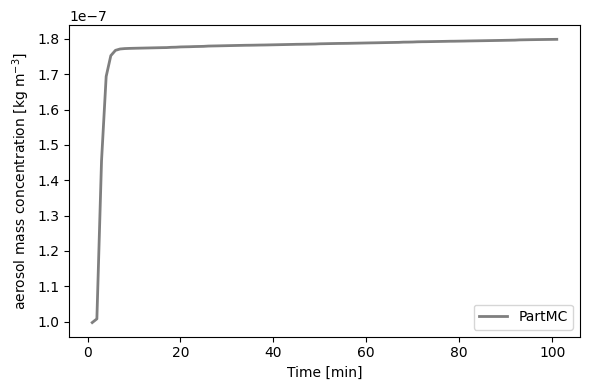

In [ ]:
with payload_path.open('rb') as f:
    loaded_payload = pickle.load(f)

loaded_plotter = build_plotter(
    loaded_payload['plotter_type'],
    loaded_payload['plotter_config'],
)

fig, ax = plt.subplots(figsize=(6, 4))
loaded_plotter.plot(ax=ax, prepared=loaded_payload['prepared'])
fig.tight_layout()

## Next step

Once this notebook works, create the simplified prepared-data notebook by keeping only:

1. imports
2. `pickle.load(...)`
3. `build_plotter(...)`
4. `plotter.plot(ax=ax, prepared=...)`

That simplified notebook should live at:

```text
tutorial/notebooks/00_plot_prepared/01_single_scenario_partmc.ipynb
```